<a href="https://colab.research.google.com/github/Heng1222/Ohsumed_classification/blob/acc-time-plot/task2_pytorch_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchinfo

In [ ]:
from huggingface_hub import HfApi, login, create_repo
import os
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
import time
import torch.nn as nn
import pandas as pd
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from peft import PeftModel
from torchinfo import summary
from huggingface_hub import HfApi, login, create_repo, hf_hub_download, notebook_login

# 1. 定義分類模型
class RobertaClassifier(nn.Module):
    def __init__(self, model_path_or_name, num_labels=23, freeze_backbone=True, useLoRA=False):
        super(RobertaClassifier, self).__init__()
        # 載入 RoBERTa
        self.roberta = RobertaModel.from_pretrained(model_path_or_name)
        # LoRA 掛載
        if useLoRA:
            LoRA_folder = "maxbeettww/roberta-MeSH-lora"
            self.roberta = PeftModel.from_pretrained(self.roberta, LoRA_folder)
        # 凍結 RoBERTa 參數
        if freeze_backbone:
            for param in self.roberta.parameters():
                param.requires_grad = False

        # 定義分類層 (NN Head)
        self.classifier = nn.Sequential(
            nn.Linear(768, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

        # summary model
        print("base model：\n\n", summary(self.roberta))
        print("classifer NN Head：\n\n", summary(self.classifier))

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # 使用 CLS Token 的向量
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

# 2. 資料集處理
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length', max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

# 3. 訓練與評估主程式 (支援歷史紀錄完整累加與安全回傳)
def run_experiment(model_name_or_path, train_df, test_df, num_epochs=30, useLoRA=False, folder_name="default_model_name"):
    api = HfApi()
    username = api.whoami()['name']
    repo_id = f"{username}/{folder_name}"
    create_repo(repo_id, exist_ok=True)
    uploaded_checkpoints = []

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaClassifier(model_name_or_path, num_labels=23, useLoRA=useLoRA)

    # --- [初始化紀錄清單與累積時間] ---
    history = []
    total_time = 0

    # 自動續傳邏輯
    resume_epoch = 0
    try:
        repo_files = api.list_repo_tree(repo_id)
        ckpt_folders = [f.path for f in repo_files if "checkpoint-" in f.path]
        if ckpt_folders:
            resume_epoch = max([int(f.split('-')[-1]) for f in ckpt_folders])
            uploaded_checkpoints = sorted(ckpt_folders, key=lambda x: int(x.split('-')[-1]))

            # 下載權重
            ckpt_file = hf_hub_download(repo_id=repo_id, filename="pytorch_model.bin", subfolder=f"checkpoint-{resume_epoch}")
            model.load_state_dict(torch.load(ckpt_file, map_location=device))

            # --- [核心改動：載入並接續舊的歷史紀錄] ---
            try:
                log_path = hf_hub_download(repo_id=repo_id, filename="training_history.csv")
                old_history_df = pd.read_csv(log_path)
                history = old_history_df.to_dict('records')
                total_time = history[-1]['cumulative_time_sec']
                print(f"成功載入舊日誌，目前已有 {len(history)} 筆紀錄，累積時間：{total_time:.2f}s")
            except:
                print("未偵測到舊日誌，將建立新紀錄")

            print(f"續傳成功：從 Epoch {resume_epoch+1} 開始")
    except Exception as e:
        print(f"初始化偵測進度時發生異常: {e}")

    model.to(device)

    # 資料分割與 Loader
    train_data, val_data = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])
    train_loader = DataLoader(TextDataset(train_data['title'].tolist(), train_data['label'].tolist(), tokenizer), batch_size=32, shuffle=True)
    val_loader = DataLoader(TextDataset(val_data['title'].tolist(), val_data['label'].tolist(), tokenizer), batch_size=32)
    test_loader = DataLoader(TextDataset(test_df['title'].tolist(), test_df['label'].tolist(), tokenizer), batch_size=32)

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=5e-4)
    criterion = nn.CrossEntropyLoss()

    # 訓練迴圈
    for epoch in range(resume_epoch, num_epochs):
        epoch_start = time.perf_counter()

        # Training
        model.train()
        train_preds, train_labels_current = [], []
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            optimizer.zero_grad()
            ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            logits = model(ids, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            train_labels_current.extend(labels.cpu().numpy())

        # Validation
        model.eval()
        val_preds_current, val_labels_current = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
                logits = model(ids, mask)
                val_preds_current.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_labels_current.extend(labels.cpu().numpy())

        epoch_end = time.perf_counter()
        duration = epoch_end - epoch_start
        total_time += duration

        t_acc = accuracy_score(train_labels_current, train_preds)
        v_acc = accuracy_score(val_labels_current, val_preds_current)

        # 儲存 Epoch 數據
        history.append({
            'epoch': epoch + 1,
            'train_acc': t_acc,
            'val_acc': v_acc,
            'epoch_duration_sec': duration,
            'cumulative_time_sec': total_time
        })

        # --- [每輪同步 Checkpoint 與 CSV] ---
        curr_count = epoch + 1
        ckpt_dir = "./ckpt_tmp"
        os.makedirs(ckpt_dir, exist_ok=True)
        torch.save(model.state_dict(), f"{ckpt_dir}/pytorch_model.bin")

        remote_f = f"checkpoint-{curr_count}"
        api.upload_folder(folder_path=ckpt_dir, repo_id=repo_id, path_in_repo=remote_f)
        uploaded_checkpoints.append(remote_f)

        # 即時更新雲端 CSV
        pd.DataFrame(history).to_csv("training_history.csv", index=False)
        api.upload_file(path_or_fileobj="training_history.csv", path_in_repo="training_history.csv", repo_id=repo_id)

        # 保持最新兩個版本
        if len(uploaded_checkpoints) > 2:
            old = uploaded_checkpoints.pop(0)
            try: api.delete_folder(path_in_repo=old, repo_id=repo_id)
            except: pass

        print(f"Epoch {curr_count} - Train Acc: {t_acc:.4f}, Val Acc: {v_acc:.4f}, Time: {duration:.2f}s")

    # --- [最終處理邏輯：解決 UnboundLocalError 並上傳] ---
    # 即使迴圈沒跑，也強制執行最後一次驗證以獲取回傳值
    print("\n--- 執行最終評估與模型上傳 ---")
    model.eval()
    final_val_preds, final_val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            logits = model(ids, mask)
            final_val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            final_val_labels.extend(labels.cpu().numpy())

    # 只有在本次有跑過訓練的情況下才更新最終模型
    if resume_epoch < num_epochs:
        final_dir = "./final_model"
        os.makedirs(final_dir, exist_ok=True)
        torch.save(model.state_dict(), f"{final_dir}/pytorch_model.bin")
        tokenizer.save_pretrained(final_dir)
        api.upload_folder(folder_path=final_dir, repo_id=repo_id, path_in_repo="final_model")

        # 再次確保最終 CSV 已上傳
        pd.DataFrame(history).to_csv("training_history.csv", index=False)
        api.upload_file(path_or_fileobj="training_history.csv", path_in_repo="training_history.csv", repo_id=repo_id)
        print(f"所有資料已成功同步至: {repo_id}")
    else:
        print(f"目標 Epoch ({num_epochs}) 已達標，跳過模型更新。")

    return final_val_labels, final_val_preds

# 4. 執行區
if __name__ == "__main__":
    # 登入
    notebook_login()

    # 資料讀取
    url = 'https://github.com/Heng1222/Ohsumed_classification/blob/main/classification_data/ohsumed_dataset.csv?raw=true'
    full_df = pd.read_csv(url)[['label', 'title']]

    # 分類標籤數字化
    unique_labels = sorted(full_df['label'].unique())
    label_to_id = {l: i for i, l in enumerate(unique_labels)}
    full_df['label'] = full_df['label'].map(label_to_id)

    # --- [修正後的統一採樣邏輯] ---
    min_size = full_df['label'].value_counts().min()
    # 使用 sample 搭配 groupby，並確保結果重設索引後 label 欄位還在
    full_df = full_df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(n=min_size, random_state=42)
    ).reset_index(drop=True)
    # -----------------------------

    # 分割訓練與測試
    # 此時 full_df 已經是一個乾淨的 DataFrame，欄位包含 'label' 和 'title'
    train_df, test_df = train_test_split(
        full_df,
        test_size=0.1,
        random_state=42,
        stratify=full_df['label']
    )

    # 執行實驗

    # 實驗 1: 使用 原版RoBERTa
    # print("Running Experiment with Base RoBERTa...")
    # run_experiment('roberta-base', train_df, test_df, folder_name = "RoBERTa_based")

    # 實驗 2: 使用 MLM
    print("Running Experiment with Custom RoBERTa...")
    run_experiment('maxbeettww/roberta-ohsumed-mlm', train_df, test_df, folder_name = "RoBERTa_MLM")

    # 實驗 3: 使用 LoRA
    # print("Running Experiment with RoBERTa + LoRA...")
    # run_experiment('roberta-base', train_df, test_df, useLoRA = True, folder_name = "RoBERTa_LoRA")

/tmp/ipython-input-3869936239.py:240: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_df = full_df.groupby('label', group_keys=False).apply(


Running Experiment with Custom RoBERTa...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...l_model/pytorch_model.bin:   7%|6         | 33.5MB /  504MB            

No files have been modified since last commit. Skipping to prevent empty commit.


所有資料已成功同步至: Alyssalai/RoBERTa_MLM


正在從 Alyssalai/RoBERTa_MLM 下載訓練日誌...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


training_history.csv: 0.00B [00:00, ?B/s]

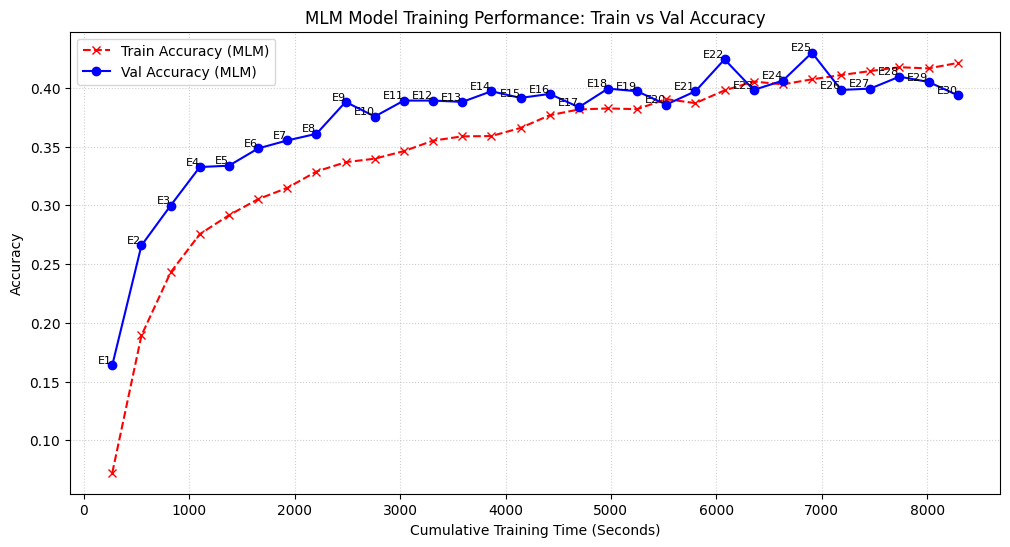

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# 1. 設定你的資訊
repo_id = "Alyssalai/RoBERTa_MLM"  # 指向你剛剛跑完的 MLM 倉庫

try:
    # 2. 下載訓練歷史紀錄
    print(f"正在從 {repo_id} 下載訓練日誌...")
    log_path = hf_hub_download(repo_id=repo_id, filename="training_history.csv")
    df = pd.read_csv(log_path)

    # 3. 繪製圖表
    plt.figure(figsize=(12, 6))

    # 畫出訓練準確度 (紅色虛線)
    plt.plot(df['cumulative_time_sec'], df['train_acc'],
             marker='x', linestyle='--', color='r', label='Train Accuracy (MLM)')

    # 畫出驗證準確度 (藍色實線)
    plt.plot(df['cumulative_time_sec'], df['val_acc'],
             marker='o', linestyle='-', color='b', label='Val Accuracy (MLM)')

    # 4. 在點旁邊標註 Epoch (E1, E2...E30)
    for i, row in df.iterrows():
        # 我們通常標在驗證集點上面，比較清楚
        plt.text(row['cumulative_time_sec'], row['val_acc'], f"E{int(row['epoch'])}",
                 fontsize=8, verticalalignment='bottom', horizontalalignment='right')

    # 圖表設定
    plt.title('MLM Model Training Performance: Train vs Val Accuracy')
    plt.xlabel('Cumulative Training Time (Seconds)')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # 顯示最佳準確度數值
    max_acc = df['val_acc'].max()
    max_epoch = df.loc[df['val_acc'].idxmax(), 'epoch']

    plt.show()

except Exception as e:
    print(f"繪圖失敗，請確認雲端是否有檔案：{e}")